## 1. Install and Import Dependencies

In [12]:
import os
import json
from azure.storage.blob import BlobServiceClient
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

import tiktoken

# Initialize tokenizer (using GPT-3.5/4 encoding which is common)
tokenizer = tiktoken.get_encoding("cl100k_base")
print("✓ Tiktoken tokenizer loaded (cl100k_base encoding)")

✓ Tiktoken tokenizer loaded (cl100k_base encoding)


## 2. Configure Azure Storage Connection

In [4]:
# Azure Storage Configuration
AZURE_STORAGE_CONNECTION_STRING = os.environ.get('AZURE_STORAGE_CONNECTION_STRING')
CONTAINER_NAME = 'clean'  # Container with cleaned data
WORKS_PREFIX = 'dtic/works/'  # Prefix for cleaned DTIC works

# Verify connection string
if not AZURE_STORAGE_CONNECTION_STRING:
    raise ValueError("AZURE_STORAGE_CONNECTION_STRING environment variable not set!")

print("✓ Configuration loaded")
print(f"  Container: {CONTAINER_NAME}")
print(f"  Works prefix: {WORKS_PREFIX}")

✓ Configuration loaded
  Container: clean
  Works prefix: dtic/works/


## 3. Connect to Azure Blob Storage

In [5]:
# Initialize Blob Service Client
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)
print("✓ Connected to Azure Blob Storage")

✓ Connected to Azure Blob Storage


## 4. Find Longest Abstract

This cell scans all clean DTIC works and finds the longest abstract length.

In [9]:
# Find longest abstract and collect all data
max_length = 0
max_abstract = None
max_work_id = None
total_works = 0
works_with_abstracts = 0
abstract_lengths = []  # Store all abstract lengths for distribution
abstract_word_counts = []  # Store word counts for distribution
abstracts = []  # Store all abstracts for further analysis

print("Scanning clean DTIC works for abstracts...")
blob_list = container_client.list_blobs(name_starts_with=WORKS_PREFIX)

for blob in tqdm(blob_list):
    total_works += 1
    
    # Download and parse blob
    blob_client = container_client.get_blob_client(blob.name)
    blob_data = blob_client.download_blob().readall()
    
    try:
        work_data = json.loads(blob_data)
        abstract = work_data.get('abstract')
        
        if abstract:
            works_with_abstracts += 1
            abstract_length = len(abstract)
            abstract_lengths.append(abstract_length)  # Collect all lengths
            abstract_word_counts.append(len(abstract.split()))  # Collect word counts
            abstracts.append(abstract)  # Store the entire abstract
            
            if abstract_length > max_length:
                max_length = abstract_length
                max_abstract = abstract
                max_work_id = work_data.get('id')
                
    except json.JSONDecodeError:
        continue

# Calculate word and token counts for the longest abstract
if max_abstract:
    word_count = len(max_abstract.split())
    # Approximate token count (tokens are typically 0.75 words on average for English)
    approximate_tokens = int(word_count * 1.33)  # ~4/3 ratio

print(f"\n✓ Analysis complete!")
print(f"  Total works scanned: {total_works}")
print(f"  Works with abstracts: {works_with_abstracts}")
print(f"  Longest abstract length: {max_length} characters")
print(f"  Word count: {word_count} words")
print(f"  Approximate tokens: {approximate_tokens} tokens (estimated)")
print(f"  Work ID: {max_work_id}")
print(f"  Total abstracts stored: {len(abstracts)}")

Scanning clean DTIC works for abstracts...


28071it [08:08, 57.41it/s]


✓ Analysis complete!
  Total works scanned: 28071
  Works with abstracts: 27124
  Longest abstract length: 15318 characters
  Word count: 752 words
  Approximate tokens: 1000 tokens (estimated)
  Work ID: work_dba29763-fe9a-5084-8ff7-7e1fbacdafa5
  Total abstracts stored: 27124


## 5. View Longest Abstract (Optional)

Display a preview of the longest abstract found.

In [7]:
# Display preview of the longest abstract
if max_abstract:
    preview_length = 500  # Show first 500 characters
    print(f"Longest abstract ({max_length} characters):")
    print(f"\nPreview (first {preview_length} chars):")
    print("-" * 80)
    print(max_abstract[:preview_length])
    if len(max_abstract) > preview_length:
        print(f"\n... ({len(max_abstract) - preview_length} more characters)")
    print("-" * 80)
else:
    print("No abstract found.")

Longest abstract (15318 characters):

Preview (first 500 chars):
--------------------------------------------------------------------------------
<p>
                    For a linear flow
                    
                      <math alttext="normal upper Phi">
                        <semantics>
                          <mi mathvariant="normal">
                            Φ
                            
                          </mi>
                          <annotation>\Phi</annotation>
                        </semantics>
                      </math>
                    
                    on a vector bundle
                   

... (14818 more characters)
--------------------------------------------------------------------------------


## 6. Distribution of Abstract Lengths

Plot a histogram of abstract lengths with log-scale bins.

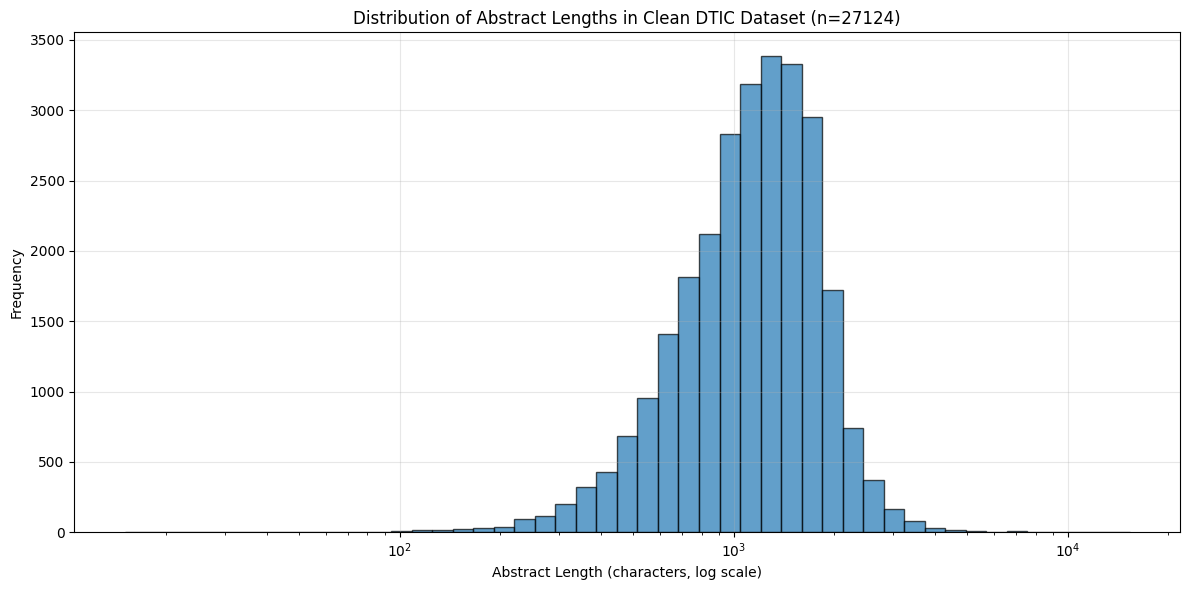


Statistics:
  Mean: 1222 characters
  Median: 1160 characters
  Std Dev: 575 characters
  Min: 15 characters
  Max: 15318 characters
  25th percentile: 823 characters
  75th percentile: 1544 characters


In [13]:
if abstract_lengths:
    # Create log-scale bins
    min_length = min(abstract_lengths)
    max_length_for_bins = max(abstract_lengths)
    
    # Create logarithmic bins from 10^1 to 10^log10(max_length)
    log_bins = np.logspace(np.log10(max(1, min_length)), np.log10(max_length_for_bins), num=50)
    
    # Create the histogram
    plt.figure(figsize=(12, 6))
    plt.hist(abstract_lengths, bins=log_bins, edgecolor='black', alpha=0.7)
    plt.xscale('log')
    plt.xlabel('Abstract Length (characters, log scale)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Abstract Lengths in Clean DTIC Dataset (n={len(abstract_lengths)})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nStatistics:")
    print(f"  Mean: {np.mean(abstract_lengths):.0f} characters")
    print(f"  Median: {np.median(abstract_lengths):.0f} characters")
    print(f"  Std Dev: {np.std(abstract_lengths):.0f} characters")
    print(f"  Min: {min_length} characters")
    print(f"  Max: {max_length_for_bins} characters")
    print(f"  25th percentile: {np.percentile(abstract_lengths, 25):.0f} characters")
    print(f"  75th percentile: {np.percentile(abstract_lengths, 75):.0f} characters")
else:
    print("No abstract lengths to plot.")

## 7. Distribution of Abstract Word Counts

Plot a histogram of abstract word counts with log-scale bins.

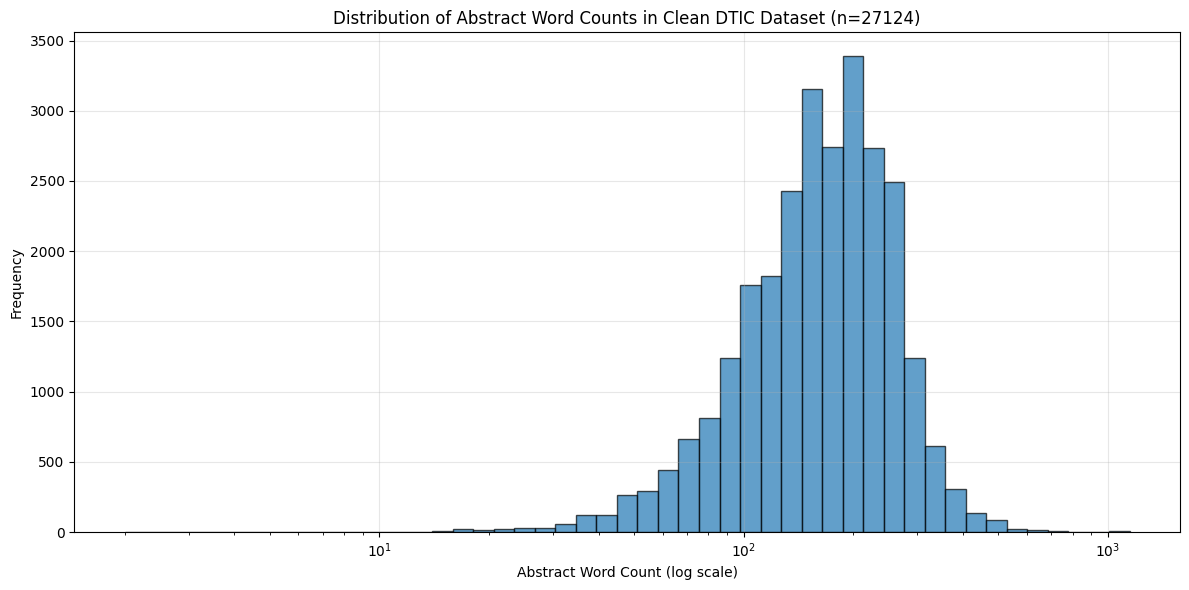


Statistics:
  Mean: 175 words
  Median: 166 words
  Std Dev: 80 words
  Min: 2 words
  Max: 1148 words
  25th percentile: 119 words
  75th percentile: 222 words


In [14]:
if abstract_word_counts:
    # Create log-scale bins
    min_words = min(abstract_word_counts)
    max_words = max(abstract_word_counts)
    
    # Create logarithmic bins from 10^1 to 10^log10(max_words)
    log_bins = np.logspace(np.log10(max(1, min_words)), np.log10(max_words), num=50)
    
    # Create the histogram
    plt.figure(figsize=(12, 6))
    plt.hist(abstract_word_counts, bins=log_bins, edgecolor='black', alpha=0.7)
    plt.xscale('log')
    plt.xlabel('Abstract Word Count (log scale)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Abstract Word Counts in Clean DTIC Dataset (n={len(abstract_word_counts)})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nStatistics:")
    print(f"  Mean: {np.mean(abstract_word_counts):.0f} words")
    print(f"  Median: {np.median(abstract_word_counts):.0f} words")
    print(f"  Std Dev: {np.std(abstract_word_counts):.0f} words")
    print(f"  Min: {min_words} words")
    print(f"  Max: {max_words} words")
    print(f"  25th percentile: {np.percentile(abstract_word_counts, 25):.0f} words")
    print(f"  75th percentile: {np.percentile(abstract_word_counts, 75):.0f} words")
else:
    print("No abstract word counts to plot.")

## 8. Distribution of Abstract Token Counts (Word Pieces)

Count tokens using tiktoken tokenizer and plot the distribution. Tokens (word pieces) are what transformer models actually use.

Counting tokens for all abstracts...


100%|██████████| 27124/27124 [00:02<00:00, 11141.09it/s]



✓ Token counting complete!
  Total abstracts processed: 27124


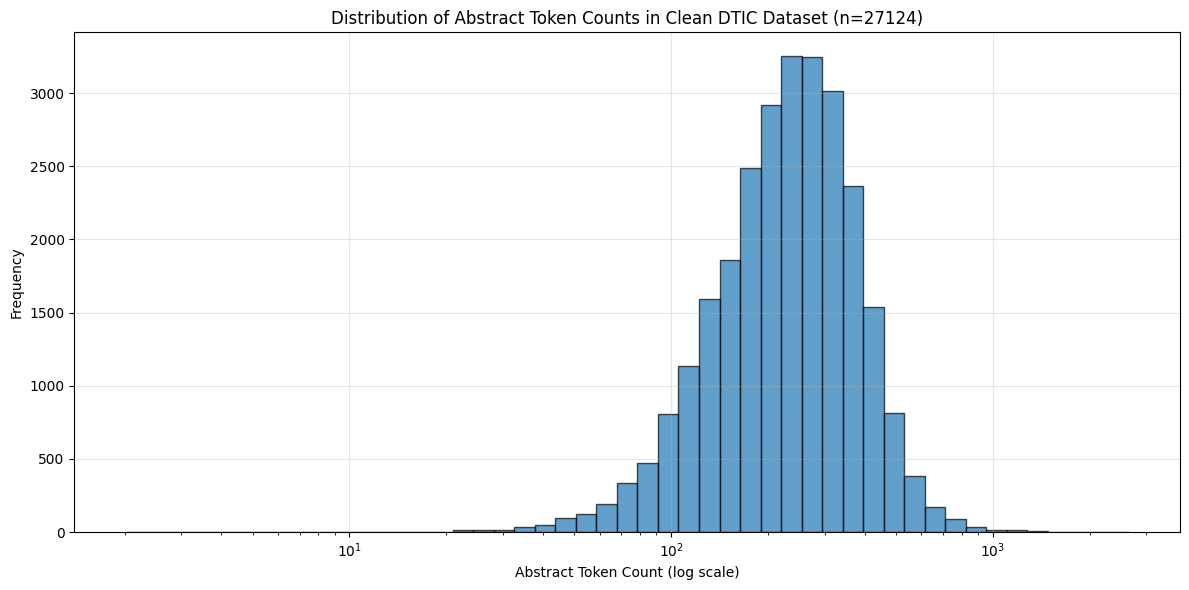


Statistics:
  Mean: 252 tokens
  Median: 234 tokens
  Std Dev: 128 tokens
  Min: 2 tokens
  Max: 2665 tokens
  25th percentile: 164 tokens
  75th percentile: 319 tokens
  90th percentile: 406 tokens
  95th percentile: 468 tokens
  99th percentile: 643 tokens


In [16]:
# Count tokens for all abstracts
print("Counting tokens for all abstracts...")
abstract_token_counts = []

for abstract in tqdm(abstracts):
    token_count = len(tokenizer.encode(abstract))
    abstract_token_counts.append(token_count)

print(f"\n✓ Token counting complete!")
print(f"  Total abstracts processed: {len(abstract_token_counts)}")

if abstract_token_counts:
    # Create log-scale bins
    min_tokens = min(abstract_token_counts)
    max_tokens = max(abstract_token_counts)
    
    # Create logarithmic bins from 10^1 to 10^log10(max_tokens)
    log_bins = np.logspace(np.log10(max(1, min_tokens)), np.log10(max_tokens), num=50)
    
    # Create the histogram
    plt.figure(figsize=(12, 6))
    plt.hist(abstract_token_counts, bins=log_bins, edgecolor='black', alpha=0.7)
    plt.xscale('log')
    plt.xlabel('Abstract Token Count (log scale)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Abstract Token Counts in Clean DTIC Dataset (n={len(abstract_token_counts)})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nStatistics:")
    print(f"  Mean: {np.mean(abstract_token_counts):.0f} tokens")
    print(f"  Median: {np.median(abstract_token_counts):.0f} tokens")
    print(f"  Std Dev: {np.std(abstract_token_counts):.0f} tokens")
    print(f"  Min: {min_tokens} tokens")
    print(f"  Max: {max_tokens} tokens")
    print(f"  25th percentile: {np.percentile(abstract_token_counts, 25):.0f} tokens")
    print(f"  75th percentile: {np.percentile(abstract_token_counts, 75):.0f} tokens")
    print(f"  90th percentile: {np.percentile(abstract_token_counts, 90):.0f} tokens")
    print(f"  95th percentile: {np.percentile(abstract_token_counts, 95):.0f} tokens")
    print(f"  99th percentile: {np.percentile(abstract_token_counts, 99):.0f} tokens")
else:
    print("No abstract token counts to plot.")